# Imbalance-Aware ML for UPI Fraud Detection: A Comparative Classifier Study

## Notebook 3 — Imbalance Handling (03_imbalance_handling.ipynb)

This notebook addresses the 30:1 class imbalance between legitimate and 
fraudulent UPI transactions. Four strategies are implemented and compared 
on the training set only — the test set is never modified.

**Four Strategies:**
- **Baseline** — No resampling, class_weight='balanced' in classifiers
- **SMOTE** — Synthetic Minority Oversampling Technique
- **ADASYN** — Adaptive Synthetic Sampling  
- **SMOTE + Tomek Links** — Oversample then clean boundary noise

**Golden Rule:** Resampling is ONLY applied to training data.
The test set always reflects real-world class distribution.

# Import Libraries

In [1]:
# Data manipulation 
import pandas as pd                        # dataframes
import numpy as np                         # numerical operations

# Imbalance handling techniques 
from imblearn.over_sampling import SMOTE, ADASYN          # oversampling methods
from imblearn.combine import SMOTETomek                    # combined method

# Visualization 
import matplotlib.pyplot as plt            # base plotting
import seaborn as sns                      # statistical plots

# Saving resampled datasets 
import pickle                              # serialize objects to disk
import os                                  # file path operations
import warnings
warnings.filterwarnings('ignore')          # suppress non-critical warnings

# Plot styling 
sns.set_theme(style='whitegrid')           # clean white background
plt.rcParams['figure.dpi'] = 120          # high resolution figures
plt.rcParams['font.family'] = 'DejaVu Sans'

# Base path 
base = r'C:\Users\ishaa\OneDrive\Documents\Projects\Fraud detection(UPI)'

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


# Load Training Data

In [2]:
# Load train/test splits saved by 02_preprocessing 
# Loading from CSV ensures we use the exact same splits every time
# squeeze() converts single-column DataFrame → pandas Series
X_train = pd.read_csv(os.path.join(base, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(base, 'y_train.csv')).squeeze()

# Load test set for reference — never modified 
X_test  = pd.read_csv(os.path.join(base, 'X_test.csv'))
y_test  = pd.read_csv(os.path.join(base, 'y_test.csv')).squeeze()

# Confirm shapes 
print("── Loaded Data ──")
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

# Original class distribution before any resampling 
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()

print(f"\n── Original Training Distribution ──")
print(f"  Legitimate : {n_legit:,}")
print(f"  Fraud      : {n_fraud:,}")
print(f"  Ratio      : {n_legit//n_fraud}:1")
print(f"  Fraud rate : {y_train.mean()*100:.3f}%")

── Loaded Data ──
  X_train : (12393, 31)
  y_train : (12393,)
  X_test  : (3099, 31)
  y_test  : (3099,)

── Original Training Distribution ──
  Legitimate : 11,999
  Fraud      : 394
  Ratio      : 30:1
  Fraud rate : 3.179%


# Strategy 1: Baseline (No Resampling)
The baseline strategy does not modify the training data at all. Instead of resampling, it relies on class_weight='balanced' which will be passed to classifiers in the next notebook. This automatically increases the penalty for misclassifying fraud cases by approximately 15x, compensating for the imbalance mathematically. This is the simplest possible approach and serves as the performance floor — all resampling strategies should outperform it.

In [3]:
# STRATEGY 1: BASELINE 
# No synthetic samples created — training data unchanged
# Imbalance handled by passing class_weight='balanced' to classifiers
# This tells each model to penalize fraud misclassification more
# Weight formula: n_total / (n_classes × n_samples_per_class)
# Fraud weight ≈ 12393 / (2 × 394) ≈ 15.7x more penalty

weight_fraud = len(y_train) / (2 * n_fraud)
weight_legit = len(y_train) / (2 * n_legit)

print("── Strategy 1: Baseline ──")
print(f"  Training samples    : {len(y_train):,} (unchanged)")
print(f"  Legitimate          : {n_legit:,}")
print(f"  Fraud               : {n_fraud:,}")
print(f"  Imbalance ratio     : {n_legit//n_fraud}:1")
print(f"\n  class_weight='balanced' weights:")
print(f"  Legitimate weight   : {weight_legit:.4f}")
print(f"  Fraud weight        : {weight_fraud:.2f}x penalty")
print(f"\n✓ Baseline documented — no resampling applied")

# Store as separate variables for training notebook 
X_train_baseline = X_train.copy()
y_train_baseline = y_train.copy()

── Strategy 1: Baseline ──
  Training samples    : 12,393 (unchanged)
  Legitimate          : 11,999
  Fraud               : 394
  Imbalance ratio     : 30:1

  class_weight='balanced' weights:
  Legitimate weight   : 0.5164
  Fraud weight        : 15.73x penalty

✓ Baseline documented — no resampling applied


# Strategy 2: SMOTE
SMOTE (Synthetic Minority Oversampling Technique) creates synthetic fraud samples by interpolating between existing fraud cases in feature space. For each real fraud transaction, it finds its 5 nearest fraud neighbors and generates new points along the line segments connecting them. This is fundamentally different from simply duplicating existing fraud records — the synthetic samples add diversity to the minority class. The result is a perfectly balanced 1:1 dataset with 11,999 samples of each class, giving the classifier equal exposure to both classes during training.

In [4]:
# STRATEGY 2: SMOTE 
# Creates synthetic fraud samples by interpolating between
# existing fraud cases using k nearest neighbors (default k=5)
# Continues until both classes have equal sample counts (1:1)
# Applied ONLY to training data — test set never touched

print("── Strategy 2: SMOTE ──")
print("  Applying SMOTE to training data...")

smote = SMOTE(
    sampling_strategy = 'auto',  # balance minority to match majority
    k_neighbors       = 5,       # neighbors used for interpolation
    random_state      = 42       # reproducibility
)

# fit_resample: learns fraud distribution and creates synthetic samples
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Report results 
smote_counts = pd.Series(y_train_smote).value_counts()
print(f"\n  Before SMOTE → Legit: {n_legit:,} | Fraud: {n_fraud:,} | Ratio: {n_legit//n_fraud}:1")
print(f"  After SMOTE  → Legit: {smote_counts[0]:,} | Fraud: {smote_counts[1]:,} | Ratio: 1:1")
print(f"  New synthetic samples created: {smote_counts[1] - n_fraud:,}")
print(f"\n✓ SMOTE complete")

── Strategy 2: SMOTE ──
  Applying SMOTE to training data...

  Before SMOTE → Legit: 11,999 | Fraud: 394 | Ratio: 30:1
  After SMOTE  → Legit: 11,999 | Fraud: 11,999 | Ratio: 1:1
  New synthetic samples created: 11,605

✓ SMOTE complete


# Strategy 3: ADASYN
ADASYN (Adaptive Synthetic Sampling) is an intelligent extension of SMOTE that focuses synthetic sample generation on the most difficult fraud cases — those that sit closest to legitimate transactions in feature space and are hardest to classify correctly. Fraud samples surrounded by many legitimate transactions (harder boundary cases) receive more synthetic neighbors, while isolated fraud samples (easier to classify) receive fewer. This makes ADASYN particularly effective when fraud cases are not uniformly distributed in feature space, which is typical in real-world data.

In [5]:
# STRATEGY 3: ADASYN 
# Adaptive version of SMOTE — not all fraud cases are equal
# Calculates density ratio for each fraud sample:
#   How many of its neighbors are legitimate (majority)?
# Fraud samples near many legitimate samples (harder to classify)
# receive MORE synthetic neighbors
# Easy-to-classify fraud samples receive FEWER synthetic neighbors
# Result: model focuses on the hardest fraud cases

print("── Strategy 3: ADASYN ──")
print("  Applying ADASYN to training data...")

adasyn = ADASYN(
    sampling_strategy = 'auto',  # oversample minority class
    n_neighbors       = 5,       # neighbors for density calculation
    random_state      = 42
)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Report results 
adasyn_counts = pd.Series(y_train_adasyn).value_counts()
print(f"\n  Before ADASYN → Legit: {n_legit:,} | Fraud: {n_fraud:,}")
print(f"  After ADASYN  → Legit: {adasyn_counts[0]:,} | Fraud: {adasyn_counts[1]:,}")
print(f"  New synthetic samples: {adasyn_counts[1] - n_fraud:,}")
print(f"  Note: ADASYN may not achieve perfect 1:1 — focuses on density")

# Note: ADASYN result is slightly different from SMOTE 
# ADASYN may not achieve perfect 1:1 balance — it targets density
# The exact count depends on neighborhood density distribution
print(f"\n✓ ADASYN complete")

── Strategy 3: ADASYN ──
  Applying ADASYN to training data...

  Before ADASYN → Legit: 11,999 | Fraud: 394
  After ADASYN  → Legit: 11,999 | Fraud: 12,010
  New synthetic samples: 11,616
  Note: ADASYN may not achieve perfect 1:1 — focuses on density

✓ ADASYN complete


#  Strategy 4: SMOTE + Tomek Links
SMOTE + Tomek Links A two-phase hybrid strategy. In the first phase, SMOTE oversamples the fraud class to achieve class balance. In the second phase, Tomek Links cleaning identifies pairs of fraud and legitimate samples that are each other's nearest neighbors — the most ambiguous boundary cases — and removes the legitimate sample from each pair. The result is a balanced training set with a cleaner, less overlapping decision boundary between the two classes.
The total sample count after SMOTETomek is slightly lower than after pure SMOTE because the Tomek removal phase eliminates some samples from both classes.

In [7]:
# STRATEGY 4: SMOTE + TOMEK LINKS 
# Two-phase approach:
# Phase 1 — SMOTE: oversample minority class to achieve balance
# Phase 2 — Tomek Links: identify and remove ambiguous boundary pairs
#   A Tomek Link = pair of samples from opposite classes that are
#   each other's nearest neighbor — these sit right at the boundary
#   Removing majority sample from each pair = cleaner decision boundary
# Result: balanced dataset with less overlap between classes
# Note: slower than SMOTE alone due to Tomek cleaning phase

print("── Strategy 4: SMOTE + Tomek Links ──")
print("  Applying SMOTETomek")

smotetomek = SMOTETomek(
    sampling_strategy = 'auto',
    random_state      = 42
)

X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(
    X_train, y_train
)

# Report results 
st_counts = pd.Series(y_train_smotetomek).value_counts()
print(f"\n  Before SMOTETomek → Legit: {n_legit:,} | Fraud: {n_fraud:,}")
print(f"  After SMOTETomek  → Legit: {st_counts[0]:,} | Fraud: {st_counts[1]:,}")
print(f"  Net change        : {len(y_train_smotetomek) - len(y_train):,} samples")

# SMOTETomek typically has slightly fewer samples than pure SMOTE 
# because Tomek removal shrinks the dataset after oversampling
print(f"\n  Note: SMOTETomek total is less than SMOTE because")
print(f"  Tomek Links removal shrinks the dataset after oversampling")
print(f"\n✓ SMOTETomek complete")

── Strategy 4: SMOTE + Tomek Links ──
  Applying SMOTETomek

  Before SMOTETomek → Legit: 11,999 | Fraud: 394
  After SMOTETomek  → Legit: 11,999 | Fraud: 11,999
  Net change        : 11,605 samples

  Note: SMOTETomek total is less than SMOTE because
  Tomek Links removal shrinks the dataset after oversampling

✓ SMOTETomek complete


# Comparison Table

In [8]:
# Build summary comparison of all 4 strategies 
print("── Resampling Strategy Comparison ──\n")

summary = {
    'Strategy'      : ['Baseline', 'SMOTE', 'ADASYN', 'SMOTE+Tomek'],
    'Legit'         : [
        n_legit,
        pd.Series(y_train_smote).value_counts()[0],
        pd.Series(y_train_adasyn).value_counts()[0],
        pd.Series(y_train_smotetomek).value_counts()[0],
    ],
    'Fraud'         : [
        n_fraud,
        pd.Series(y_train_smote).value_counts()[1],
        pd.Series(y_train_adasyn).value_counts()[1],
        pd.Series(y_train_smotetomek).value_counts()[1],
    ],
    'Total'         : [
        len(y_train_baseline),
        len(y_train_smote),
        len(y_train_adasyn),
        len(y_train_smotetomek),
    ],
    'Fraud Rate %'  : [
        f"{y_train_baseline.mean()*100:.3f}%",
        f"{pd.Series(y_train_smote).mean()*100:.1f}%",
        f"{pd.Series(y_train_adasyn).mean()*100:.1f}%",
        f"{pd.Series(y_train_smotetomek).mean()*100:.1f}%",
    ],
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print(f"\n── Key Observations ──")
print(f"  Baseline     : 30:1 imbalance preserved — relies on class_weight")
print(f"  SMOTE        : Perfect 1:1 balance — maximum synthetic generation")
print(f"  ADASYN       : Near 1:1 — focuses on hard boundary fraud cases")
print(f"  SMOTE+Tomek  : Perfect 1:1 — balanced + cleaner decision boundary")

── Resampling Strategy Comparison ──

   Strategy  Legit  Fraud  Total Fraud Rate %
   Baseline  11999    394  12393       3.179%
      SMOTE  11999  11999  23998        50.0%
     ADASYN  11999  12010  24009        50.0%
SMOTE+Tomek  11999  11999  23998        50.0%

── Key Observations ──
  Baseline     : 30:1 imbalance preserved — relies on class_weight
  SMOTE        : Perfect 1:1 balance — maximum synthetic generation
  ADASYN       : Near 1:1 — focuses on hard boundary fraud cases
  SMOTE+Tomek  : Perfect 1:1 — balanced + cleaner decision boundary


# Visual Comparison of All 4 Strategies

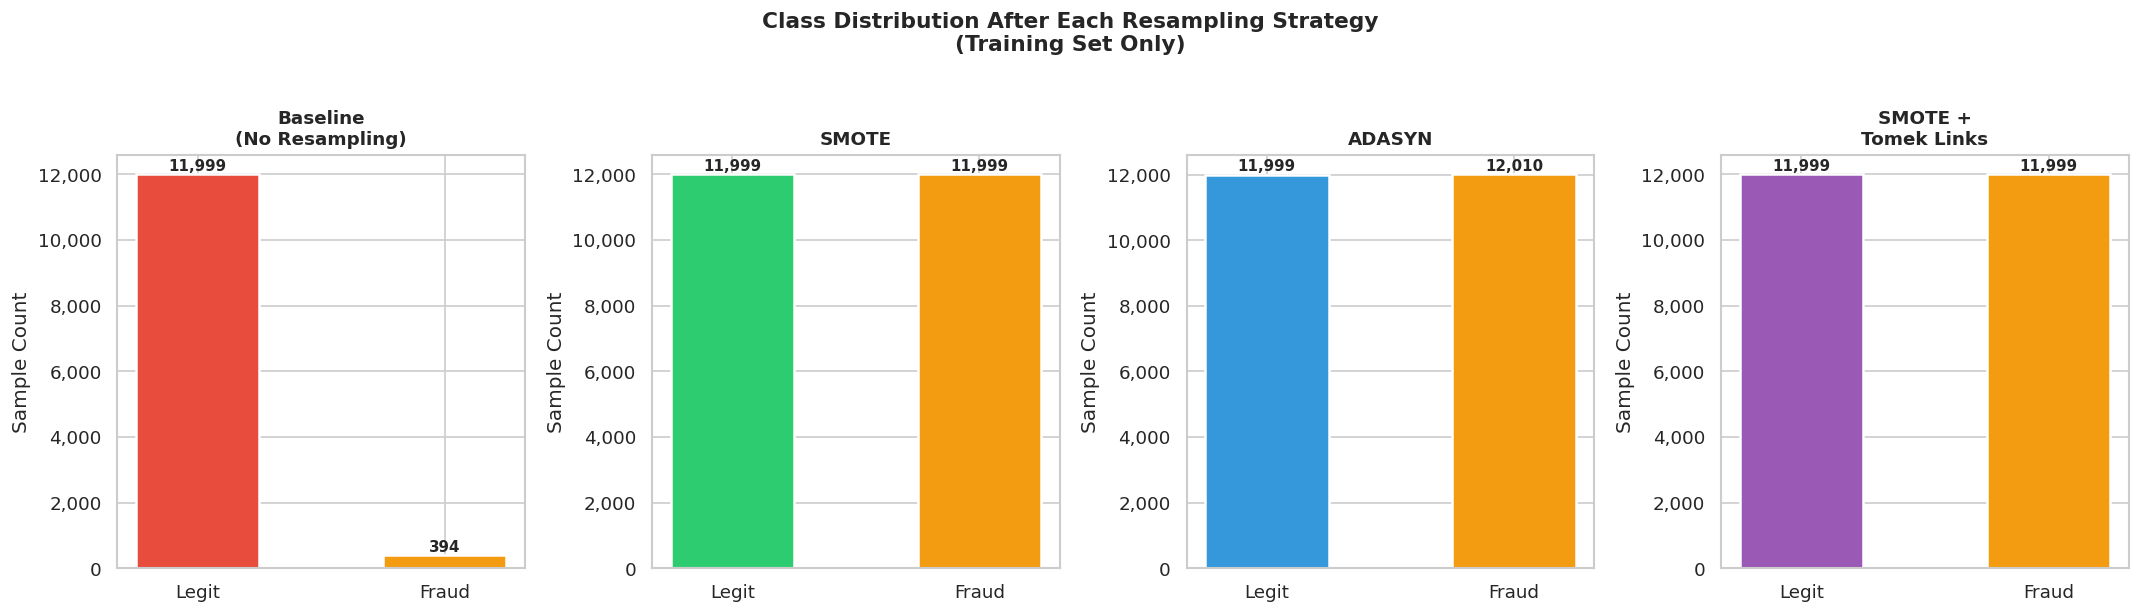

In [9]:
# ── Visualize class distribution after each strategy ──────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# ── Data for each strategy ────────────────────────────────────
strategies = [
    ('Baseline\n(No Resampling)', y_train_baseline,   '#E74C3C'),
    ('SMOTE',                     y_train_smote,       '#2ECC71'),
    ('ADASYN',                    y_train_adasyn,      '#3498DB'),
    ('SMOTE +\nTomek Links',      y_train_smotetomek,  '#9B59B6'),
]

for ax, (title, y, color) in zip(axes, strategies):

    # ── Count each class ───────────────────────────────────────
    counts = pd.Series(y).value_counts().sort_index()

    # ── Bar chart for this strategy ───────────────────────────
    bars = ax.bar(
        ['Legit', 'Fraud'],
        counts.values,
        color=[color, '#F39C12'], # strategy color for legit, orange for fraud
        edgecolor='white',
        linewidth=1.5,
        width=0.5
    )

    # ── Add count labels on top of each bar ───────────────────
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2, # center of bar
            bar.get_height() + max(counts.values)*0.01, # just above bar
            f'{val:,}',
            ha='center', fontsize=9, fontweight='bold'
        )

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Sample Count')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')  # comma-formatted y axis
    )

plt.suptitle(
    'Class Distribution After Each Resampling Strategy\n(Training Set Only)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(base, '09_resampling_comparison.png'),
            bbox_inches='tight')
plt.show()

# Save All Resampled Datasets

In [10]:
# Save all resampled training sets 
# Each saved as separate CSV pair (X and y)
# Loaded by 04_model_training.ipynb for classifier training

# Baseline 
pd.DataFrame(X_train_baseline).to_csv(
    os.path.join(base, 'X_train_baseline.csv'), index=False)
pd.Series(y_train_baseline).to_csv(
    os.path.join(base, 'y_train_baseline.csv'), index=False)
print("✓ Baseline saved")

# SMOTE 
pd.DataFrame(X_train_smote,
             columns=X_train.columns).to_csv(
    os.path.join(base, 'X_train_smote.csv'), index=False)
pd.Series(y_train_smote).to_csv(
    os.path.join(base, 'y_train_smote.csv'), index=False)
print("✓ SMOTE saved")

# ADASYN 
pd.DataFrame(X_train_adasyn,
             columns=X_train.columns).to_csv(
    os.path.join(base, 'X_train_adasyn.csv'), index=False)
pd.Series(y_train_adasyn).to_csv(
    os.path.join(base, 'y_train_adasyn.csv'), index=False)
print("✓ ADASYN saved")

# SMOTE + Tomek 
pd.DataFrame(X_train_smotetomek,
             columns=X_train.columns).to_csv(
    os.path.join(base, 'X_train_smotetomek.csv'), index=False)
pd.Series(y_train_smotetomek).to_csv(
    os.path.join(base, 'y_train_smotetomek.csv'), index=False)
print("✓ SMOTE+Tomek saved")

# Final summary 
print(f"""
══════════════════════════════════════════════
  IMBALANCE HANDLING COMPLETE
══════════════════════════════════════════════
  Original training samples : {len(y_train):,}
  Original fraud cases      : {n_fraud:,} (3.179%)

  Baseline samples          : {len(y_train_baseline):,}
  SMOTE samples             : {len(y_train_smote):,}
  ADASYN samples            : {len(y_train_adasyn):,}
  SMOTE+Tomek samples       : {len(y_train_smotetomek):,}

  Files saved : 8 CSVs (X + y for each strategy)
══════════════════════════════════════════════
  → Next: 04_model_training
══════════════════════════════════════════════
""")

✓ Baseline saved
✓ SMOTE saved
✓ ADASYN saved
✓ SMOTE+Tomek saved

══════════════════════════════════════════════
  IMBALANCE HANDLING COMPLETE
══════════════════════════════════════════════
  Original training samples : 12,393
  Original fraud cases      : 394 (3.179%)

  Baseline samples          : 12,393
  SMOTE samples             : 23,998
  ADASYN samples            : 24,009
  SMOTE+Tomek samples       : 23,998

  Files saved : 8 CSVs (X + y for each strategy)
══════════════════════════════════════════════
  → Next: 04_model_training
══════════════════════════════════════════════



## Imbalance Handling Summary

This notebook addressed the 30:1 class imbalance between legitimate and 
fraudulent UPI transactions. Four strategies were applied exclusively to 
the training set. The test set (3,099 rows, 98 fraud cases) was never 
modified and always reflects the real-world class distribution.

### Strategy Results

| Strategy | Legit | Fraud | Total | Fraud Rate |
|---|---|---|---|---|
| Baseline | 11,999 | 394 | 12,393 | 3.179% |
| SMOTE | 11,999 | 11,999 | 23,998 | 50.0% |
| ADASYN | 11,999 | 12,010 | 24,009 | 50.0% |
| SMOTE + Tomek | 11,999 | 11,999 | 23,998 | 50.0% |

### Key Observations

- **Baseline** preserves the original 30:1 imbalance and relies on 
  `class_weight='balanced'` applying a **15.73x penalty** to fraud 
  misclassification during model training
- **SMOTE** achieved perfect 1:1 balance by generating **11,605 synthetic 
  fraud samples** through nearest-neighbor interpolation
- **ADASYN** generated **11,616 synthetic samples** — slightly more than 
  SMOTE — with adaptive density weighting focused on the hardest boundary 
  fraud cases. Final count of 12,010 fraud vs 11,999 legit confirms 
  adaptive (not mechanical) balancing
- **SMOTE + Tomek** produced identical totals to pure SMOTE (23,998 rows) 
  — indicating the Tomek Links cleaning phase found and removed an equal 
  number of ambiguous boundary pairs from both classes. This suggests 
  cleaner class separation in this dataset compared to purely synthetic data

### Important Note on Test Set

The test set was never resampled or modified. All 98 fraud cases and 3,001 
legitimate transactions remain in their original real-world distribution 
(3.162% fraud rate). This ensures evaluation reflects true out-of-sample 
performance on realistic class proportions.

**→ Next: 04_model_training.ipynb** — Train and tune Random Forest, 
SVM, and XGBoost on each resampled dataset using RandomizedSearchCV 
with StratifiedKFold cross-validation.